# TP1 - UdeSA Panorámica

## Parte 1: carga, ancla y features

Este notebook integra el trabajo del grupo. La lógica reutilizable se mantiene en `panorama/` para evitar duplicación y facilitar la integración de las próximas etapas.

En esta primera sección se cargan las tres imágenes, se fija la imagen central como ancla, se convierten a escala de grises y se extraen keypoints/descriptores con SIFT.

In [1]:
from pathlib import Path
import importlib
import sys

import cv2
import matplotlib.pyplot as plt

# El notebook puede abrirse desde tp1_panoramica/ o desde la raíz del repo.
NOTEBOOK_DIR = Path.cwd()
PROJECT_DIR = (
    NOTEBOOK_DIR
    if (NOTEBOOK_DIR / "panorama").is_dir()
    else NOTEBOOK_DIR / "tp1_panoramica"
)
if not (PROJECT_DIR / "panorama").is_dir():
    raise FileNotFoundError(
        "No se encontró la carpeta panorama/. Abrí el notebook desde el proyecto."
    )
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

importlib.invalidate_caches()
import panorama.features as features
features = importlib.reload(features)  # Recarga cambios de features.py sin reiniciar el kernel.
adaptive_non_maximal_suppression = features.adaptive_non_maximal_suppression
extract_triplet_features = features.extract_triplet_features
load_triplet = features.load_triplet
match_triplet_to_anchor = features.match_triplet_to_anchor
matched_point_coordinates = features.matched_point_coordinates

INPUT_DIR = PROJECT_DIR / "inputs"
DATASET = "cuadro"  # Cambiar a "udesa" para correr el mismo pipeline.
ANCHOR_INDEX = 1
DETECTOR = "sift"
NFEATURES = 1500
NFEATURES_ANMS = 500
LOWE_RATIO = 0.75
MAX_MATCHES_TO_DRAW = 60

### 1. Carga de la secuencia y elección de la ancla

Usamos la imagen central (`*_1.jpg`) como ancla. Las homografías posteriores transformarán las imágenes `0` y `2` hacia este sistema de coordenadas.

In [2]:
images = load_triplet(INPUT_DIR, DATASET)
anchor_image = images[ANCHOR_INDEX]

for index, image in images.items():
    role = "ancla" if index == ANCHOR_INDEX else "lateral"
    print(f"Imagen {index} ({role}): {image.shape[1]} x {image.shape[0]} px")

Imagen 0 (lateral): 3072 x 4096 px
Imagen 1 (ancla): 3072 x 4096 px
Imagen 2 (lateral): 3072 x 4096 px


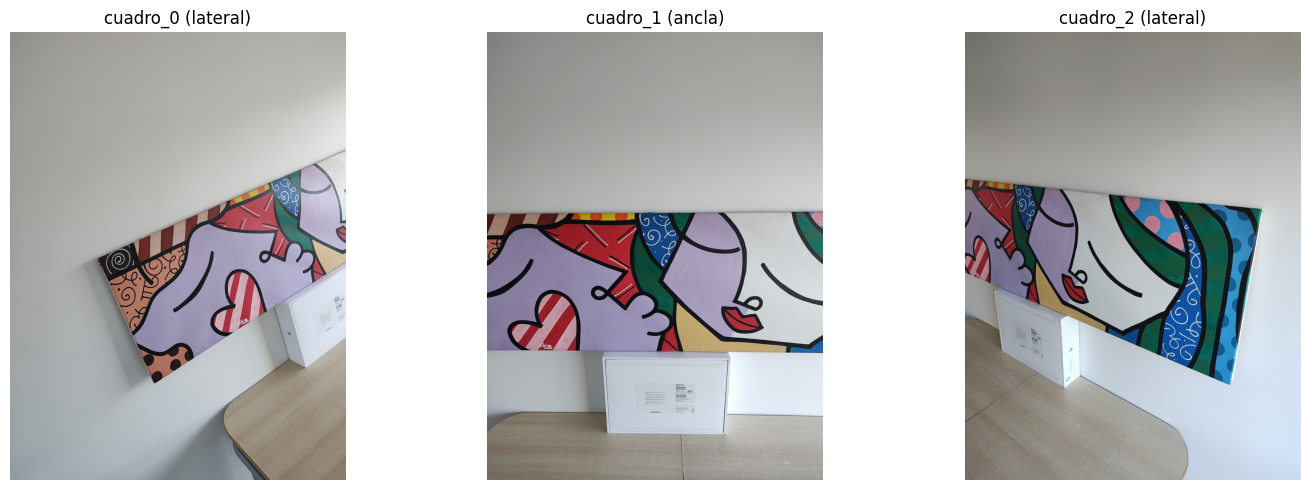

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for index, axis in enumerate(axes):
    axis.imshow(cv2.cvtColor(images[index], cv2.COLOR_BGR2RGB))
    title = "ancla" if index == ANCHOR_INDEX else "lateral"
    axis.set_title(f"{DATASET}_{index} ({title})")
    axis.axis("off")
plt.tight_layout()

### 2 y 3. Escala de grises, keypoints y descriptores

Por ahora se extraen features iniciales. La supresión A-NMS se agregará antes del matching para distribuir mejor los puntos en toda la imagen.

#### Pipeline teorico
1. Primero detectar puntos de interes (keypoints)
    
    Objetivo: decidir si un objeto esta en una escena comparando partes reconocibles de una imagen contra otra
    
    Alta repetibilidad: encontrar el mismo punto aunque cambie el POV
    
    invarianza a iluminacion, POV, escala, rotacion

    Eficiencia computacional

    Detectores: Harris, sift, surf, shi tomasi, FAST, orb, brisk, superpoint (deep learning)

2. Keypoint vs descriptor
    Keypoint: corrdenada localmente distintiva de la img, ej esquinas, blobs, textura

    Descriptor: vector que codifica la estructura local alrededor de un keypoint. Es lo que se usa para comprar ese keypooint con otros.

3. Matching entres descriptores de dos imagenes

In [4]:
grays, keypoints, descriptors = extract_triplet_features(
    images, detector_name=DETECTOR, nfeatures=NFEATURES
)

for index in sorted(images):
    descriptor_shape = None if descriptors[index] is None else descriptors[index].shape
    print(
        f"Imagen {index}: {len(keypoints[index])} keypoints; "
        f"descriptores: {descriptor_shape}"
    )

Imagen 0: 1500 keypoints; descriptores: (1500, 128)
Imagen 1: 1500 keypoints; descriptores: (1500, 128)
Imagen 2: 1500 keypoints; descriptores: (1500, 128)


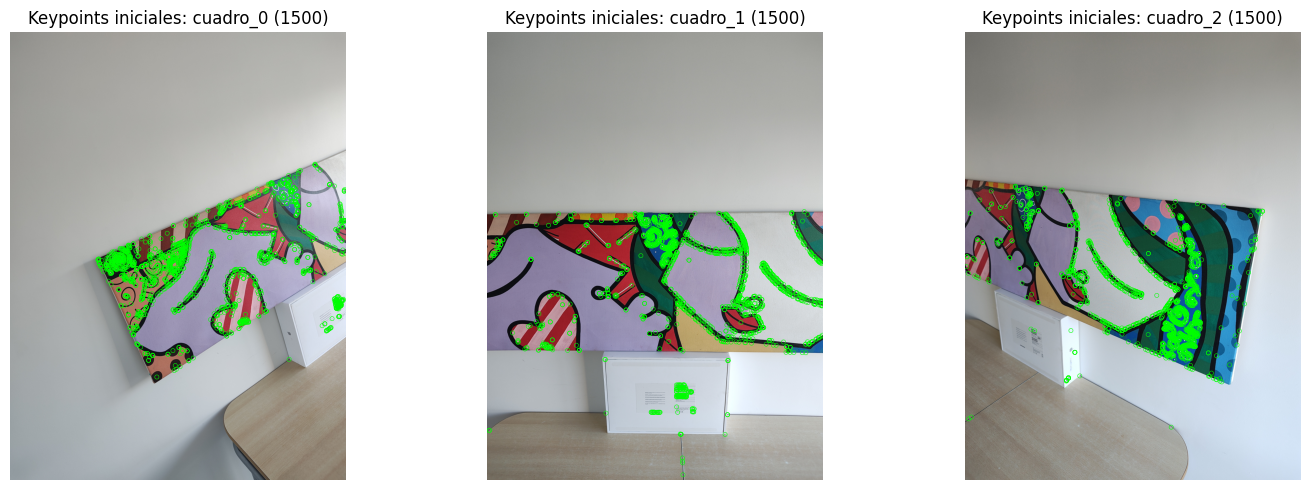

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for index, axis in enumerate(axes):
    axis.imshow(cv2.cvtColor(images[index], cv2.COLOR_BGR2RGB))
    points = [keypoint.pt for keypoint in keypoints[index]]
    if points:
        x_coords, y_coords = zip(*points)
        # Los puntos se dibujan con tamaño fijo para que se vean al reducir fotos grandes.
        axis.scatter(
            x_coords, y_coords, s=9, facecolors="none", edgecolors="lime",
            linewidths=0.45, alpha=0.8,
        )
    axis.set_title(f"Keypoints iniciales: {DATASET}_{index} ({len(points)})")
    axis.axis("off")
plt.tight_layout()

### 4. Supresión de no máxima adaptativa (A-NMS)

A-NMS conserva puntos fuertes que están separados de otros puntos con respuesta suficiente. Así evita que los keypoints queden concentrados solamente en el sector más texturado de la imagen.

In [6]:
anms_keypoints = {}
anms_descriptors = {}

for index in sorted(images):
    anms_keypoints[index], anms_descriptors[index] = (
        adaptive_non_maximal_suppression(
            keypoints[index], descriptors[index], num_features=NFEATURES_ANMS
        )
    )
    print(
        f"Imagen {index}: {len(keypoints[index])} iniciales -> "
        f"{len(anms_keypoints[index])} luego de A-NMS"
    )

Imagen 0: 1500 iniciales -> 500 luego de A-NMS
Imagen 1: 1500 iniciales -> 500 luego de A-NMS
Imagen 2: 1500 iniciales -> 500 luego de A-NMS


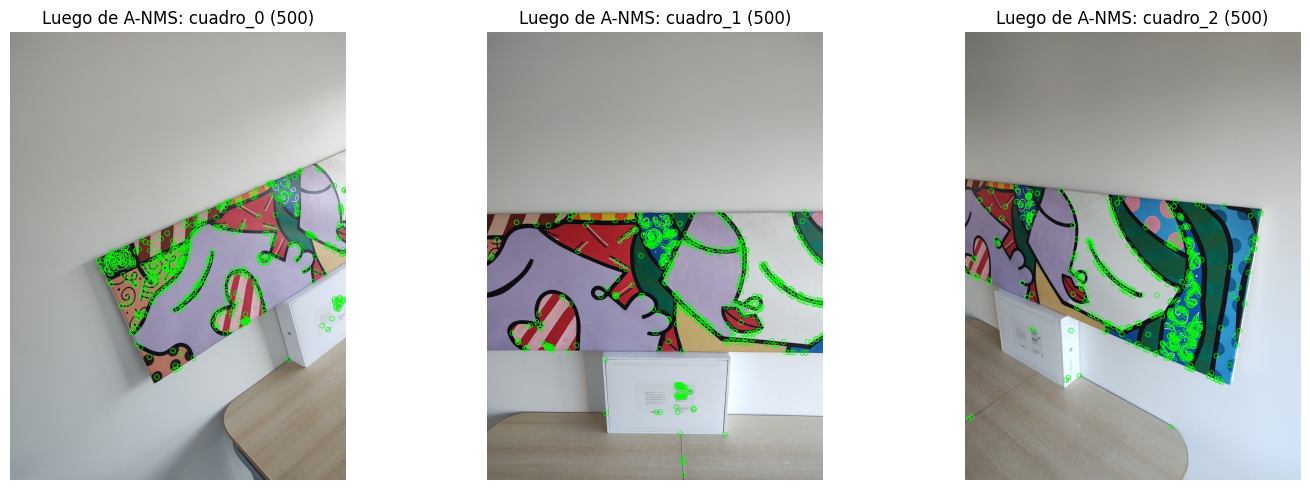

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for index, axis in enumerate(axes):
    axis.imshow(cv2.cvtColor(images[index], cv2.COLOR_BGR2RGB))
    points = [keypoint.pt for keypoint in anms_keypoints[index]]
    if points:
        x_coords, y_coords = zip(*points)
        axis.scatter(
            x_coords, y_coords, s=12, facecolors="none", edgecolors="lime",
            linewidths=0.55, alpha=0.85,
        )
    axis.set_title(f"Luego de A-NMS: {DATASET}_{index} ({len(points)})")
    axis.axis("off")
plt.tight_layout()

### 5. Asociación de características (matching)

Se buscan los dos vecinos más cercanos de cada descriptor lateral en la imagen ancla. Lowe ratio descarta un match cuando el mejor vecino no es claramente más parecido que el segundo.

In [8]:
matches_to_anchor = match_triplet_to_anchor(
    anms_descriptors,
    anchor_index=ANCHOR_INDEX,
    detector_name=DETECTOR,
    ratio=LOWE_RATIO,
)

matched_points = {}
for source_index, matches in matches_to_anchor.items():
    source_points, anchor_points = matched_point_coordinates(
        anms_keypoints[source_index], anms_keypoints[ANCHOR_INDEX], matches
    )
    matched_points[source_index] = {
        "source": source_points,
        "anchor": anchor_points,
    }
    print(
        f"{DATASET}_{source_index} → {DATASET}_{ANCHOR_INDEX}: "
        f"{len(matches)} matches tras Lowe ratio ({LOWE_RATIO})"
    )

cuadro_0 → cuadro_1: 58 matches tras Lowe ratio (0.75)
cuadro_2 → cuadro_1: 52 matches tras Lowe ratio (0.75)


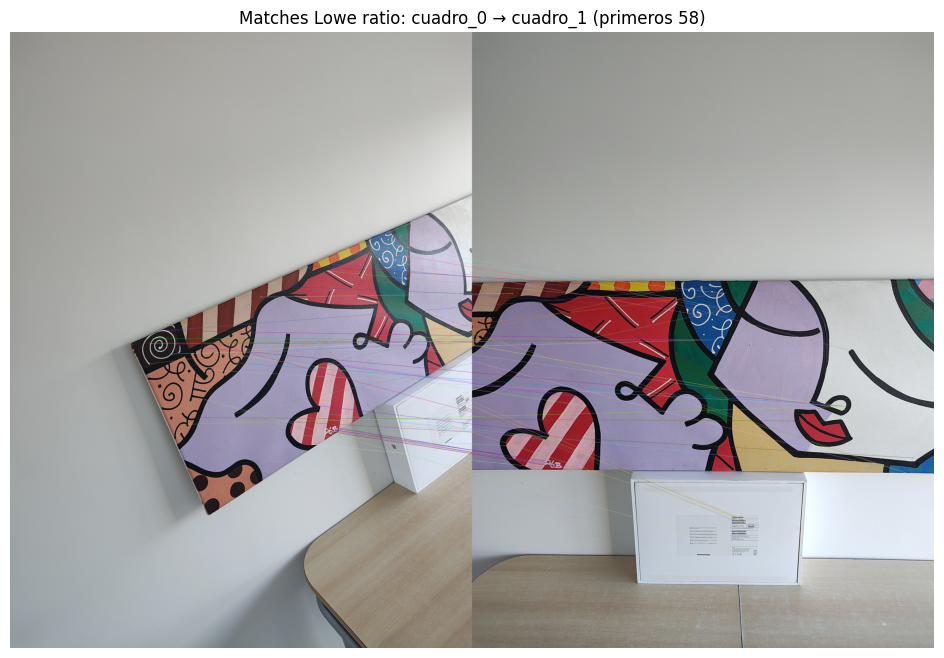

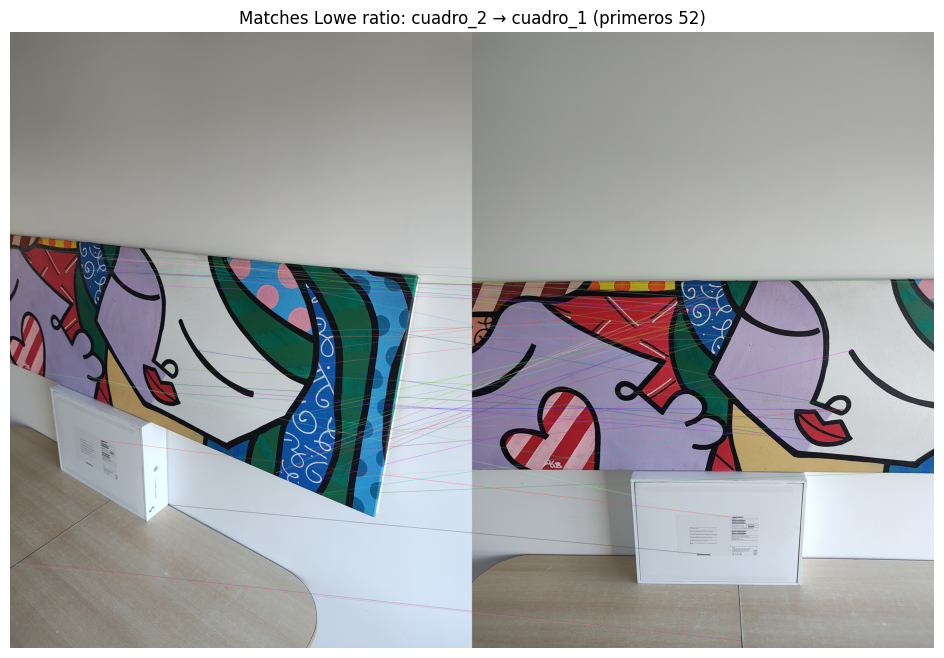

In [9]:
for source_index, matches in matches_to_anchor.items():
    matches_to_draw = sorted(matches, key=lambda match: match.distance)[:MAX_MATCHES_TO_DRAW]
    preview = cv2.drawMatches(
        images[source_index],
        anms_keypoints[source_index],
        images[ANCHOR_INDEX],
        anms_keypoints[ANCHOR_INDEX],
        matches_to_draw,
        None,
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS,
    )
    plt.figure(figsize=(18, 8))
    plt.imshow(cv2.cvtColor(preview, cv2.COLOR_BGR2RGB))
    plt.title(
        f"Matches Lowe ratio: {DATASET}_{source_index} → "
        f"{DATASET}_{ANCHOR_INDEX} (primeros {min(len(matches), MAX_MATCHES_TO_DRAW)})"
    )
    plt.axis("off")
    plt.show()

### 6. Estimación manual de homografía con DLT

En esta sección se eligen a mano 4 pares de correspondencias entre cada imagen lateral y el ancla (sin usar el matching automático de la sección anterior) y se resuelve la homografía con la implementación propia de DLT (`geometry.dlt`, sin OpenCV).

Se puede elegir los puntos clickeando directamente sobre las imágenes con `pick_correspondences` (requiere un backend interactivo de matplotlib) o cargar coordenadas ya medidas con un editor de imágenes.


In [10]:
import numpy as np

import geometry
geometry = importlib.reload(geometry)  # Recarga cambios de geometry.py sin reiniciar el kernel.


**Qué tener en cuenta al elegir los 4 pares de puntos:**

- Que no sean colineales: 3 o más puntos alineados dejan el sistema de DLT mal condicionado y la homografía queda subdeterminada en esa dirección.
- Que estén bien distribuidos en toda la región de solape, no agrupados en una esquina: los puntos concentrados en una zona chica amplifican el efecto del error de picking sobre el resto de la imagen.
- Que sean fácilmente identificables en ambas imágenes (esquinas, cruces de bordes de alto contraste) para minimizar el error de localización manual en píxeles.
- Evitar puntos cerca del borde de la imagen, donde la distorsión de lente es mayor y son más difíciles de ubicar con precisión.


In [11]:
def pick_correspondences(img_source, img_anchor, num_points=4):
    """Permite clickear a mano `num_points` correspondencias entre dos imagenes.

    Requiere un backend interactivo (ej. `%matplotlib widget` o `%matplotlib qt`).
    Primero se clickean los puntos sobre la imagen lateral y luego los mismos
    puntos, en el mismo orden, sobre la imagen ancla.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    axes[0].imshow(cv2.cvtColor(img_source, cv2.COLOR_BGR2RGB))
    axes[0].set_title(f"Click {num_points} puntos (imagen lateral)")
    axes[0].axis("off")
    axes[1].imshow(cv2.cvtColor(img_anchor, cv2.COLOR_BGR2RGB))
    axes[1].set_title("Ancla (esperando)")
    axes[1].axis("off")
    plt.tight_layout()

    source_points = plt.ginput(num_points, timeout=0)

    axes[1].set_title(f"Click los mismos {num_points} puntos, en el mismo orden")
    fig.canvas.draw()
    anchor_points = plt.ginput(num_points, timeout=0)

    plt.close(fig)
    return np.float32(source_points), np.float32(anchor_points)


In [12]:
MANUAL_SOURCE_INDICES = [index for index in sorted(images) if index != ANCHOR_INDEX]

# Cambiar a True para elegir los puntos clickeando (requiere backend interactivo).
PICK_POINTS_INTERACTIVELY = False

if PICK_POINTS_INTERACTIVELY:
    manual_correspondences = {
        source_index: pick_correspondences(images[source_index], anchor_image)
        for source_index in MANUAL_SOURCE_INDICES
    }
else:
    # TODO: reemplazar por las coordenadas (x, y) en pixeles medidas con un editor
    # de imagenes (o con pick_correspondences). Los 4 puntos de cada lista deben
    # corresponder al mismo punto fisico, en el mismo orden, en ambas imagenes.
    manual_correspondences = {
        0: (
            np.float32([[120, 90], [520, 110], [480, 360], [90, 340]]),  # puntos en <dataset>_0
            np.float32([[140, 95], [540, 100], [500, 350], [110, 330]]),  # mismos puntos en <dataset>_1 (ancla)
        ),
        2: (
            np.float32([[130, 100], [510, 120], [470, 370], [100, 350]]),  # puntos en <dataset>_2
            np.float32([[150, 90], [530, 105], [490, 360], [120, 340]]),  # mismos puntos en <dataset>_1 (ancla)
        ),
    }

for source_index in MANUAL_SOURCE_INDICES:
    source_points, _ = manual_correspondences[source_index]
    print(f"{DATASET}_{source_index} -> {DATASET}_{ANCHOR_INDEX}: {len(source_points)} puntos manuales")


cuadro_0 -> cuadro_1: 4 puntos manuales
cuadro_2 -> cuadro_1: 4 puntos manuales


In [13]:
manual_homographies = {}
for source_index in MANUAL_SOURCE_INDICES:
    source_points, anchor_points = manual_correspondences[source_index]
    manual_homographies[source_index] = geometry.dlt(source_points, anchor_points, normalize=True)
    print(f"H manual ({DATASET}_{source_index} -> {DATASET}_{ANCHOR_INDEX}):")
    print(manual_homographies[source_index])
    print()


H manual (cuadro_0 -> cuadro_1):
[[ 9.00852910e-01 -1.19509470e-02  3.00437956e+01]
 [-4.77035521e-02  9.06913739e-01  1.71143552e+01]
 [-1.43933910e-04 -4.05833889e-05  1.00000000e+00]]

H manual (cuadro_2 -> cuadro_1):
[[ 9.65403250e-01 -4.17476289e-03  2.37280713e+01]
 [-1.81241384e-02  9.87155793e-01 -7.07163083e+00]
 [-5.00183187e-05 -1.41083556e-05  1.00000000e+00]]



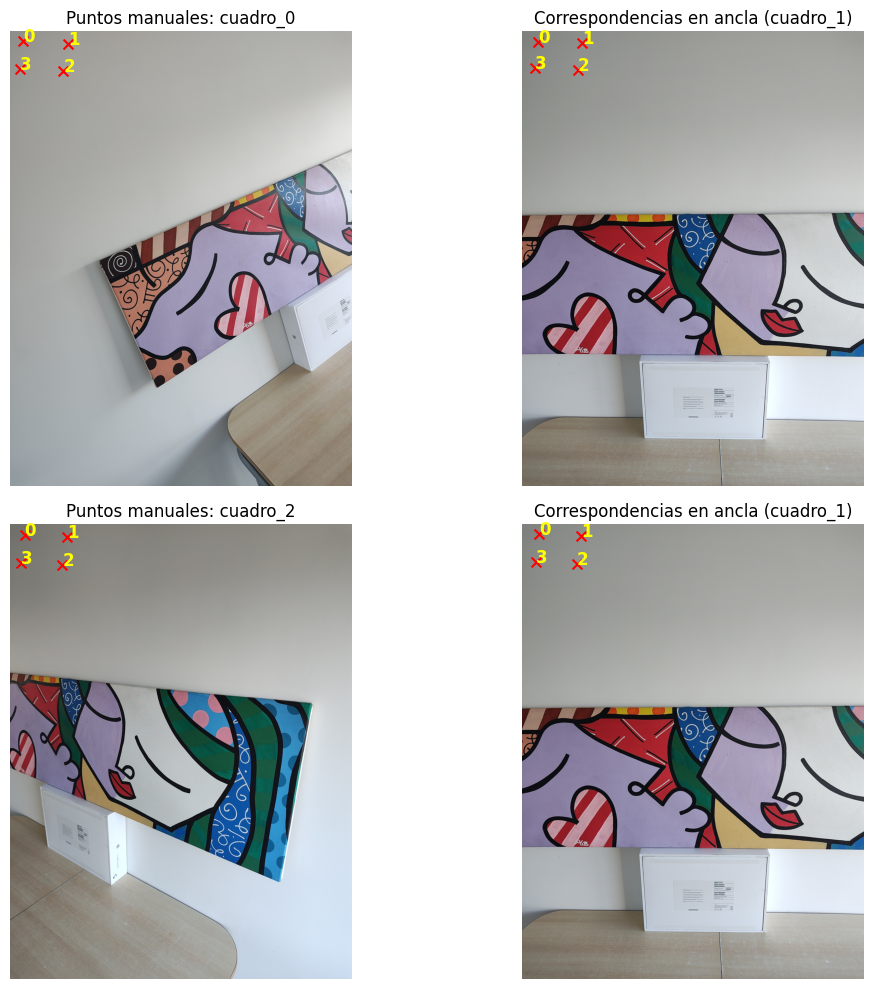

In [14]:
fig, axes = plt.subplots(len(MANUAL_SOURCE_INDICES), 2, figsize=(12, 5 * len(MANUAL_SOURCE_INDICES)))
if len(MANUAL_SOURCE_INDICES) == 1:
    axes = axes[None, :]

for row, source_index in enumerate(MANUAL_SOURCE_INDICES):
    source_points, anchor_points = manual_correspondences[source_index]
    ax_source, ax_anchor = axes[row]

    ax_source.imshow(cv2.cvtColor(images[source_index], cv2.COLOR_BGR2RGB))
    ax_source.scatter(source_points[:, 0], source_points[:, 1], c="red", s=50, marker="x")
    for point_index, (x, y) in enumerate(source_points):
        ax_source.annotate(str(point_index), (x, y), color="yellow", fontsize=12, weight="bold")
    ax_source.set_title(f"Puntos manuales: {DATASET}_{source_index}")
    ax_source.axis("off")

    ax_anchor.imshow(cv2.cvtColor(anchor_image, cv2.COLOR_BGR2RGB))
    ax_anchor.scatter(anchor_points[:, 0], anchor_points[:, 1], c="red", s=50, marker="x")
    for point_index, (x, y) in enumerate(anchor_points):
        ax_anchor.annotate(str(point_index), (x, y), color="yellow", fontsize=12, weight="bold")
    ax_anchor.set_title(f"Correspondencias en ancla ({DATASET}_{ANCHOR_INDEX})")
    ax_anchor.axis("off")

plt.tight_layout()


### 7. RANSAC para eliminación de outliers y homografía final

Se usan los matches automáticos de la sección 5 (post A-NMS y Lowe ratio) como correspondencias potencialmente ruidosas. RANSAC (implementado en `geometry.ransac`, sin OpenCV) muestrea 4 pares al azar en cada iteración, cuenta inliers por error de reproyección, y al final recalcula la homografía por cuadrados mínimos usando todos los inliers de la mejor muestra.


In [15]:
RANSAC_ITERATIONS = 2000
RANSAC_THRESHOLD_PX = 5.0
RANSAC_SEED = 0


In [16]:
ransac_homographies = {}
ransac_inlier_masks = {}

for source_index in MANUAL_SOURCE_INDICES:
    source_points = matched_points[source_index]["source"]
    anchor_points = matched_points[source_index]["anchor"]

    H, inlier_mask = geometry.ransac(
        source_points,
        anchor_points,
        num_iterations=RANSAC_ITERATIONS,
        threshold=RANSAC_THRESHOLD_PX,
        seed=RANSAC_SEED,
    )
    ransac_homographies[source_index] = H
    ransac_inlier_masks[source_index] = inlier_mask

    print(
        f"{DATASET}_{source_index} -> {DATASET}_{ANCHOR_INDEX}: "
        f"{inlier_mask.sum()}/{len(inlier_mask)} inliers"
    )
    print(H)
    print()


cuadro_0 -> cuadro_1: 14/58 inliers
[[ 1.36578983e+00 -3.61928160e-01 -1.29150390e+03]
 [ 5.44731166e-01  1.56498570e+00 -1.76460729e+03]
 [-6.61910105e-05  1.41136936e-04  1.00000000e+00]]

cuadro_2 -> cuadro_1: 7/52 inliers
[[-2.98880004e+00  7.35461334e-02  1.61581697e+03]
 [-3.78410211e+00  9.29450942e-02  2.04657277e+03]
 [-1.84950165e-03  4.54689718e-05  1.00000000e+00]]



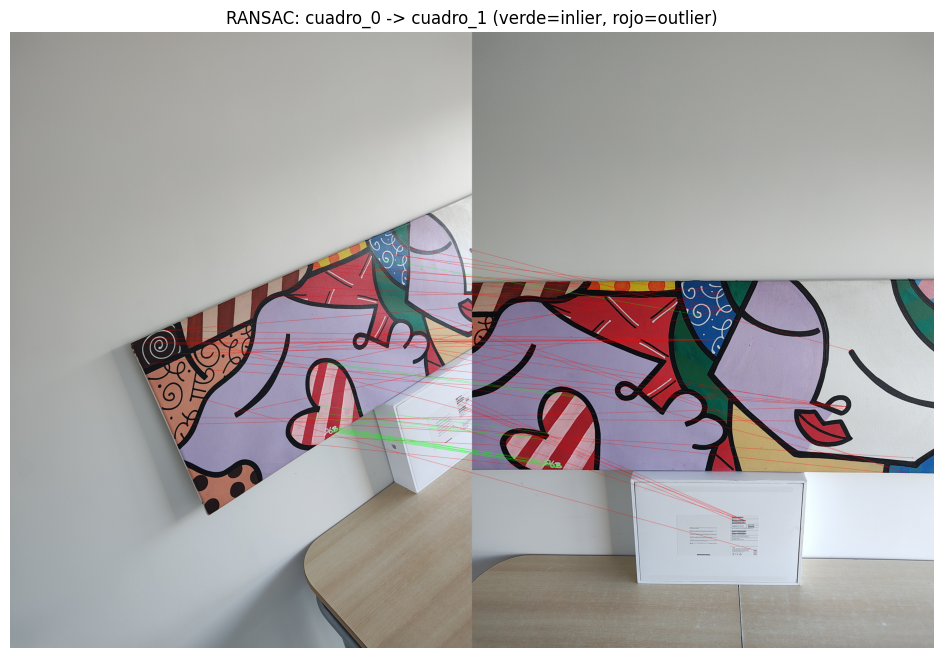

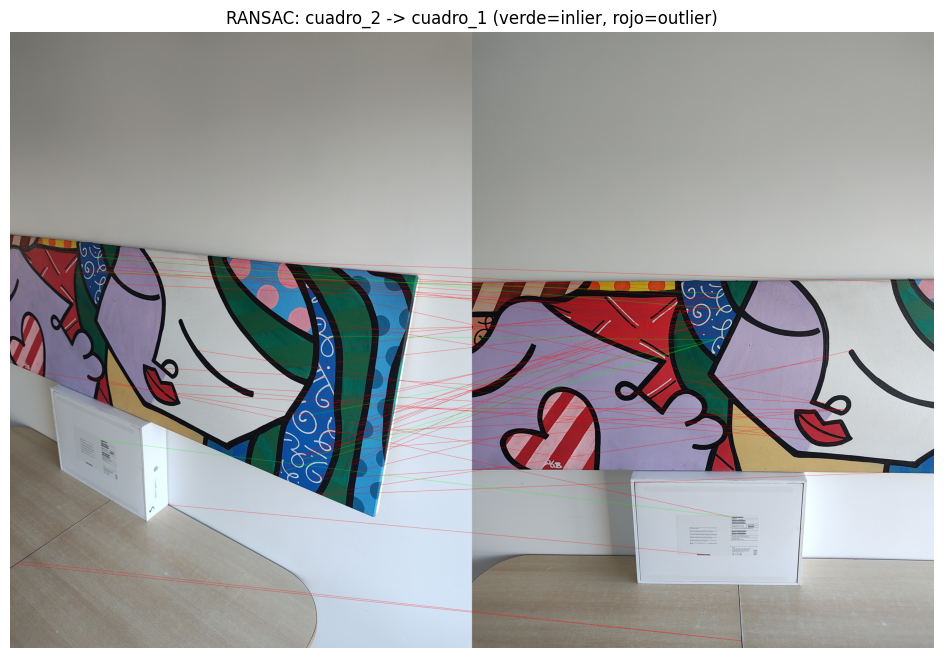

In [17]:
for source_index in MANUAL_SOURCE_INDICES:
    matches = matches_to_anchor[source_index]
    inlier_mask = ransac_inlier_masks[source_index]

    inlier_matches = [match for match, is_inlier in zip(matches, inlier_mask) if is_inlier]
    outlier_matches = [match for match, is_inlier in zip(matches, inlier_mask) if not is_inlier]

    canvas = cv2.drawMatches(
        images[source_index], anms_keypoints[source_index],
        images[ANCHOR_INDEX], anms_keypoints[ANCHOR_INDEX],
        outlier_matches, None,
        matchColor=(0, 0, 255), singlePointColor=(0, 0, 255),
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS,
    )
    canvas = cv2.drawMatches(
        images[source_index], anms_keypoints[source_index],
        images[ANCHOR_INDEX], anms_keypoints[ANCHOR_INDEX],
        inlier_matches, canvas,
        matchColor=(0, 255, 0), singlePointColor=(0, 255, 0),
        flags=cv2.DrawMatchesFlags_DRAW_OVER_OUTIMG | cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS,
    )

    plt.figure(figsize=(18, 8))
    plt.imshow(cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB))
    plt.title(
        f"RANSAC: {DATASET}_{source_index} -> {DATASET}_{ANCHOR_INDEX} "
        f"(verde=inlier, rojo=outlier)"
    )
    plt.axis("off")
    plt.show()


In [18]:
for source_index in MANUAL_SOURCE_INDICES:
    H = ransac_homographies[source_index]
    inlier_mask = ransac_inlier_masks[source_index]
    source_points = matched_points[source_index]["source"]
    anchor_points = matched_points[source_index]["anchor"]

    errors = geometry.compute_reprojection_error(
        H, source_points[inlier_mask], anchor_points[inlier_mask]
    )
    print(
        f"{DATASET}_{source_index} -> {DATASET}_{ANCHOR_INDEX}: "
        f"error de reproyeccion (inliers) -> "
        f"media: {errors.mean():.3f} px, mediana: {np.median(errors):.3f} px, "
        f"max: {errors.max():.3f} px"
    )


cuadro_0 -> cuadro_1: error de reproyeccion (inliers) -> media: 1.271 px, mediana: 1.126 px, max: 3.266 px
cuadro_2 -> cuadro_1: error de reproyeccion (inliers) -> media: 22.117 px, mediana: 0.013 px, max: 118.383 px
